# Searching for the category

For this code along we are only going to use the products DataFrame. However, if you believe there is information in other tables that can help to create categories, please feel free to explore.

In [ ]:
import pandas as pd

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1hDSzIA3_xxKtbuiFtQhy3oxxWOZopzi-/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qa = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1_B-hYrpY5aiJwqZsmDKL-YUuIOwsaiz9/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qa = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1lWcG5b3EOj7oZ7qp3XFvms1Ltvhia-R_/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_qa = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1_JJj8BVRWyXVUZyA4CSyooWqKKdaAUKc/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_qa = pd.read_csv(path)

In [ ]:
orders_cc = orders_qa.copy()
orderlines_cc = orderlines_qa.copy()
product_cc = products_qa.copy()
brands_cc = brands_qa.copy()
orders_cc["created_date"] = pd.to_datetime(orders_qa["created_date"])

In [ ]:
product_cc.head()

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364


## 1.&nbsp; Category creation by search term
Let's start by creating a column `category`. For now we'll fill this column with a blank string `""`.

In [ ]:
product_cc["category_by_type"] = ""
product_cc.head()

,sku,name,desc,price,in_stock,type,category_by_type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,


We can find all the products with certain words in their `description` using `.loc[]` and `.str.contains()`. Here we'll look at all the items that have the word `keyboard` in their description.

In [ ]:
product_cc.loc[product_cc["desc"].str.contains("keyboard", case=False)]

,sku,name,desc,price,in_stock,type,category_by_type
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,
15,MOS0021,Clearguard Moshi MacBook Pro and Air,Keyboard Protector MacBook Pro 13-inch Retina ...,24.95,0,13835403,
24,APP0277,Apple Wireless Keyboard Keyboard (OEM) Mac,Ultrathin keyboard Apple Bluetooth Spanish (un...,79.00,0,13855401,
64,HGD0012,Henge Docks Click keyboard support iMac,Base to hold the Apple Magic TrackPad and Wire...,29.00,0,8696,
365,LOG0084,Logitech Ultrathin Keyboard Cover Keyboard Cov...,Ultrathin cover and cover with Bluetooth keybo...,89.99,0,12575403,
...,...,...,...,...,...,...,...
9720,PAC2508,Replacement Magic Wireless Keyboard by Matias ...,Keyboard replacement service at the time of pu...,119.99,1,13855401,
9751,MTF0008,Mistify Clean Screens Natural 500ml.,Spray cleaning screens and keyboards.,14.99,1,12085400,
9796,ZAG0026-A,Open - Zagg Rugged Keyboard Folio iPad Messeng...,Case reconditioned keyboard and adjustable pos...,99.99,0,12575403,
9932,APP1472,Apple Magic Keyboard English International,English keyboard Mac and Apple iPad Ultrathin ...,119.00,1,13855401,


Next, we change the value in the category column to `keyboard` for all of these keyboard products.

In [ ]:
product_cc.loc[product_cc["desc"].str.contains("keyboard", case=False), "category_by_type"] = "keyboard"

Let's take a look at the effect that had on the `category` column.

In [ ]:
product_cc["category_by_type"].value_counts()

,count
category_by_type,
,9903
keyboard,89


## 2.&nbsp; Category creation using regex
We can also use a product's `name` to select products for our categories.

In [ ]:
product_cc.loc[product_cc["name"].str.contains("apple iphone", case=False)]

,sku,name,desc,price,in_stock,type,category_by_type
35,APP0308,AV Cable Adapter Apple iPhone iPad and iPod white,IPhone iPad iPod adapter and AV cable.,45.00,0,1230,
214,REP0100,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,0,"1,44E+11",
215,REP0052,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,0,"1,44E+11",
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.00,0,NaN,
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.00,0,NaN,
...,...,...,...,...,...,...,...
9790,AP20455,Like new - Apple iPhone 8 256GB Gold,Apple iPhone 8 reconditioned 256GB in Gold rea...,979.00,0,113291716,
9794,APP2482-A,Open - Apple iPhone 8 Plus 256GB Gold,Refurbished Apple iPhone 8 Plus 256GB Free Gold,1089.00,0,113281716,
9929,APP2477-A,Open - Apple iPhone 8 Plus 64GB Space Gray,Apple iPhone 8 Plus 64GB Space Gray,919.00,0,113281716,
9958,AP20467,Like new - Apple iPhone Silicone Case Cover 7 ...,Reconditioned silicone sleeve microfiber Apple...,45.00,0,11865403,


Looks like we get a lot of accessories included in this search. We can refine this using a little regex. Here, we will add `.{0,7}` at the beginning of the search: this means we will find all `apple iphone`s that have 7 or less characters preceding the term "apple iphone" - if there's 8 characters preceding the search term, it won't be found. This should help refine our search by using the nomenclature of the DataFrame to our advantage.

If you feel unsure about regex, please use [regex101](https://regex101.com/). It's really useful for checking your code, and parts of other people's code that you're unsure about.

In [ ]:
product_cc.loc[product_cc["name"].str.contains("^.{0,7}apple iphone", case=False)]

,sku,name,desc,price,in_stock,type,category_by_type
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.0,0,NaN,
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.0,0,NaN,
961,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749.0,0,NaN,
962,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639.0,0,NaN,
963,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749.0,0,NaN,
...,...,...,...,...,...,...,...
9585,APP1634-A,Open - Apple iPhone 7 Plus 32GB Black,New 32GB Apple iPhone 7 Plus Free Black,779.0,0,85651716,
9587,APP2540-A,Open - Apple iPhone Leather Folio X Baya,Leather case with box and official cover Apple,109.0,0,11865403,
9714,APP2562-A,Open - Apple iPhone Leather Case Cover Red,Reconditioned skin sheath official Apple desig...,45.0,0,11865403,
9794,APP2482-A,Open - Apple iPhone 8 Plus 256GB Gold,Refurbished Apple iPhone 8 Plus 256GB Free Gold,1089.0,0,113281716,


Now we can use the same trick as before to set the category - selecting the `category` column and setting it to the string of our choice.

In [ ]:
product_cc.loc[product_cc["name"].str.contains("^.{0,7}apple iphone", case=False), "category_by_type"] = "smartphone"

In [ ]:
product_cc["category_by_type"].value_counts()

,count
category_by_type,
,9634
smartphone,269
keyboard,89


## 3.&nbsp; One product with multiple categories
A product may fit into multiple categories. To help us create multiple categories for one product, we will use the python addition assignment `+=`. The addition assignment is a shorthand way to add something (number, string, etc...) to a variable without changing the variable name.

Let's have a look at a couple of examples.

In [ ]:
a = 10
a = a + 5
a

15

In [ ]:
a = 10
a += 5
a

15

In [ ]:
b = "Tyrannosaurus"
b = b + " rex"
b

'Tyrannosaurus rex'

In [ ]:
b = "Tyrannosaurus"
b += " rex"
b

'Tyrannosaurus rex'

Now let's look at how this can help us in our category creation.

First, we'll reset all the values in the category column to an empty string `""`.

In [ ]:
product_cc["category"] = ""

Now, let's create some categories and utilise the addition assignment.

In [ ]:
product_cc.loc[product_cc["desc"].str.contains("keyboard", case=False), "category"] += ", keyboard"
product_cc.loc[product_cc["name"].str.contains("^.{0,7}apple iphone", case=False), "category"] += ", smartphone"
product_cc.loc[product_cc["name"].str.contains("^.{0,7}apple ipod", case=False), "category"] += ", ipod"
product_cc.loc[product_cc["name"].str.contains("^.{0,7}apple ipad|tablet", case=False), "category"] += ", tablet"
product_cc.loc[product_cc["name"].str.contains("imac|mac mini|mac pro", case=False), "category"] += ", desktop"

In [ ]:
product_cc["category"].value_counts()

,count
category,
,8362
", desktop",923
", tablet",307
", smartphone",269
", keyboard",83
", ipod",42
", keyboard, tablet",4
", keyboard, desktop",2


As you can see, some products now have 2 categories instead of just one. At the end, you can use your skills with string to tidy up the opening comma and space in the `category` column.

# Challenge. Your categories
Now it's your turn. We'll reset the Dataframe so that no categories exist, and it's up to you to create the categories based on keywords in the name and description. Feel free to go wild and make as many categories as you like.
* Remember you can also use regex to refine your searches.
* Remember you can use the or operator `|` to search for multiple terms at once.
* Remember to tidy up any untidy strings at the end.

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1hDSzIA3_xxKtbuiFtQhy3oxxWOZopzi-/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qa = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1_B-hYrpY5aiJwqZsmDKL-YUuIOwsaiz9/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qa = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1lWcG5b3EOj7oZ7qp3XFvms1Ltvhia-R_/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_qa = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1_JJj8BVRWyXVUZyA4CSyooWqKKdaAUKc/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_qa = pd.read_csv(path)

In [ ]:
# Start with orderlines
merge_all= orderlines_qa.copy()

# Merge orders
merge_all = merge_all.merge(orders_qa,left_on='id_order',right_on='order_id',how='left')

# Merge products
merge_all = merge_all.merge(products_qa,on='sku',how='left')

# Extract brand code from SKU
merge_all['brand_code'] = merge_all['sku'].str[:3]

# Merge brands
merge_all = merge_all.merge(brands_qa,left_on='brand_code',right_on='short',how='left')

In [107]:
merge_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60896 entries, 0 to 60895
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 60896 non-null  int64         
 1   id_order           60896 non-null  int64         
 2   product_quantity   60896 non-null  int64         
 3   sku                60896 non-null  object        
 4   unit_price         60896 non-null  float64       
 5   date               60896 non-null  object        
 6   order_id           60896 non-null  int64         
 7   created_date       60896 non-null  datetime64[ns]
 8   total_paid         60896 non-null  float64       
 9   state              60896 non-null  object        
 10  name               59254 non-null  object        
 11  desc               59254 non-null  object        
 12  price              59254 non-null  float64       
 13  in_stock           59254 non-null  float64       
 14  type  

## 4.&nbsp; [BONUS] Using `type` to create categories
There could be another way to create categories, but this one you'll have to explore this one alone.

We have the mysterious column `type` in the `products` table. This could potentially be ready-made categories labelled with numbers instead of words. Let's investigate.

In [ ]:
category_type_df = products_qa.copy()

In [ ]:
orders_cc["created_date"] = pd.to_datetime(orders_qa["created_date"])

Here are the `type`s that have the most products.

In [ ]:
category_type_df.groupby("type").count().nlargest(10, "sku")

,sku,name,desc,price,in_stock
type,,,,,
11865403,1057,1057,1057,1057,1057
12175397,939,939,939,939,939
1298,783,783,783,783,783
11935397,562,562,562,562,562
11905404,454,454,454,454,454
1282,373,373,373,373,373
12635403,362,362,362,362,362
13835403,269,269,269,269,269
"5,74E+15",247,247,247,247,247


Let's have a look at the first `type` to see if we can make categories from this column.

In [ ]:
category_type_df.loc[category_type_df["type"] == "11865403"].sample(10)

,sku,name,desc,price,in_stock,type
196,KEN0063,Kensington Thin Back Case iPhone 5 / 5S Pink,Back Case iPhone 5 / 5S.,19.99,0,11865403
465,MUV0108,Muvit Slim Case + Screen Protector iPhone 5C W...,Slim Case + Screen Protector for iPhone 5C.,13.99,0,11865403
5333,BEL0273,Air Protect Case Belkin iPhone 7/8 SheerForce ...,Case technology against impact and wear resist...,19.99,1,11865403
7428,APP2096,Apple iPhone Silicone Case Cover 8 Plus / 7 Pl...,Ultrathin silicone case and microfiber premium...,45.00,0,11865403
4584,TWS0098,Twelve South BookBook Case for iPhone 6 / 6S b...,card holder book cover seal with iPhone 6 / 6S,69.99,0,11865403
3808,STI0008,Stil Mind London FOG Case iPhone 6 / 6S Khaki,Stilmind Protective Case for iPhone 6 / 6S,19.99,0,11865403
680,UAG0010,Urban Armor Gear Composite Case iPhone Scout S...,ultra durable and lightweight for iPhone SE / ...,34.95,0,11865403
2532,APP1154,Case Apple iPhone 6 Plus / 6s Plus Black Leath...,ultrathin leather case and microfiber premium ...,59.00,0,11865403
7038,BEL0265-A,Open - Air Protect SheerForce Case Belkin iPho...,Case anti impact and wear resistant material a...,19.99,0,11865403
8897,OTT0178,OtterBox iPhone Case Etui 8 Symmetry Dark Blue,Symmetry OtterBox protective sleeve one-piece ...,34.99,1,11865403


Looks like this is a category of phone cases.

Let's have a look at the 2nd largest type to see if that's also a clear category.

In [ ]:
category_type_df.loc[category_type_df["type"] == "12175397"].sample(10)

,sku,name,desc,price,in_stock,type
8487,PAC2388,DS418play Synology NAS Server | 2GB RAM | 24TB...,4-bay NAS server to accommodate 4K Ultra HD files,1614.95,0,12175397
3386,PAC1662,QNAP TS-453A | 4GB RAM | 32TB (4x8TB) WD Red,NAS TS-453A with 4GB of RAM Memory Hard + 32TB...,1965.99,0,12175397
8580,PAC2348,Synology DS718 + NAS Server | 16GB RAM | 16TB ...,Scalable NAS server with transcoding 4K: 4-cor...,1362.69,0,12175397
5926,QNA0204,QNAP TS-231P NAS,2-bay NAS server with 2 LAN ports and a powerf...,216.59,0,12175397
7062,SYN0168,Synology DS1817 + | 2GB RAM | NAS server Mac a...,NAS with 2GB of RAM and 8 bays compatible with...,978.89,0,12175397
4667,SYN0146,Synology NAS Server DS416Play Mac and PC,4-bay NAS served 1GB RAM transcodifiación 4K f...,434.99,0,12175397
3343,PAC1314,Pack QNAP TS-253A | 4GB RAM | 4TB IronWolf,QNAP Pack + 4GB memory RAM + 4TB (2x2TB) Seaga...,609.97,0,12175397
4360,PAC1441,Synology DS116 + Pack 4TB WD Red,1 bay NAS server + 4TB (1x4TB) Network Hard Dr...,335.38,0,12175397
7749,PAC2173,QNAP TS-251A-4G NAS Server | 4GB RAM | 20TB (2...,NAS with 4GB of RAM and two HDDs 10TB (2x10TB)...,1198.07,1,12175397
8516,PAC2237,Synology DS418 NAS Server | 2GB RAM | 12TB (4x...,NAS server 4 bays and 2GB DDR4 capable tramsmi...,940.99,0,12175397


Looks like this category is full of servers.

I wonder how many `type`s account for most of our products?

In [ ]:
n = 30
print(f"With the {n} largest types, we account for {((category_type_df.groupby('type').count().nlargest(n, 'sku')['sku'].sum()) / (category_type_df.shape[0]) * 100).round(2)}% of all products.")

With the 30 largest types, we account for 78.4% of all products.


Looks like we can simply investigate 30 types and set the categories, then the remaining 20% of products can have the category `other`.

Use the skills you learnt above to change the category for each type.

In [ ]:
merge_all

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,name,desc,price,in_stock,type,brand_code,short,long
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1.0,12755395,OWC,OWC,OWC
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0.0,5720,IOT,IOT,iOttie
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1.0,13005399,APP,APP,Apple
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",IMac desktop computer 27 inch Retina 5K RAM 32...,3209.00,0.0,1282,PAC,PAC,Pack
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0.0,1298,CRU,CRU,Crucial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple


In [ ]:
merge_all['discount_per_unit']=merge_all['price']-merge_all['unit_price']
merge_all

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,name,desc,price,in_stock,type,brand_code,short,long,discount_per_unit
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1.0,12755395,OWC,OWC,OWC,13.50
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0.0,5720,IOT,IOT,iOttie,3.96
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1.0,13005399,APP,APP,Apple,16.81
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",IMac desktop computer 27 inch Retina 5K RAM 32...,3209.00,0.0,1282,PAC,PAC,Pack,643.01
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0.0,1298,CRU,CRU,Crucial,16.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01


In [ ]:
merge_all['discount_total']= merge_all['discount_per_unit']* merge_all['product_quantity']
merge_all

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,name,desc,price,in_stock,type,brand_code,short,long,discount_per_unit,discount_total
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1.0,12755395,OWC,OWC,OWC,13.50,13.50
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0.0,5720,IOT,IOT,iOttie,3.96,3.96
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1.0,13005399,APP,APP,Apple,16.81,16.81
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",IMac desktop computer 27 inch Retina 5K RAM 32...,3209.00,0.0,1282,PAC,PAC,Pack,643.01,643.01
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0.0,1298,CRU,CRU,Crucial,16.09,16.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,15.01
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,30.02
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,30.02
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,45.03


In [ ]:
merge_all['revenue'] = merge_all['unit_price'] * merge_all['product_quantity']
merge_all

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,...,desc,price,in_stock,type,brand_code,short,long,discount_per_unit,discount_total,revenue
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1.0,12755395,OWC,OWC,OWC,13.50,13.50,47.49
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,...,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0.0,5720,IOT,IOT,iOttie,3.96,3.96,18.99
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1.0,13005399,APP,APP,Apple,16.81,16.81,72.19
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,...,IMac desktop computer 27 inch Retina 5K RAM 32...,3209.00,0.0,1282,PAC,PAC,Pack,643.01,643.01,2565.99
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,...,SSD hard drive and high-speed performance with...,76.99,0.0,1298,CRU,CRU,Crucial,16.09,16.09,60.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,15.01,9.99
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,30.02,19.98
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,30.02,19.98
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,APP,APP,Apple,15.01,45.03,29.97


Why revenue ≠ total_paid in real ecommerce data:
✔ Discounts
✔ Shipping fees
✔ Vouchers / coupons
✔ Partial refunds
✔ Rounding differences

In [ ]:
top_products = (merge_all.groupby(['sku', 'name'], as_index=False)['revenue'].sum().sort_values('revenue', ascending=False))
top_products

,sku,name,revenue
927,APP2075,"Apple MacBook Pro 15 ""Core i7 Touch Bar 29Ghz ...",215485.71
926,APP2074,"Apple MacBook Pro 15 ""Core i7 Touch Bar 28GHz ...",156383.56
2780,LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",139377.77
1158,APP2489,Apple iPhone 64GB Space Gray X,134657.00
922,APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",129397.08
...,...,...,...
4433,PUR0107,Puro Just Cavalli Swan iPhone Case Passion / 5...,3.99
3378,NTE0087-A,Open - NewerTech Cable HDMI to HDMI 1.4A 090m,2.82
4334,PAR0037,Upper body MiniDrone Parrot Jumping Sumo White,1.99
4807,SEV0018,IMac RAM installation service,0.01


In [ ]:
top_products['revenue_share_pct'] = top_products['revenue']*100 / merge_all['revenue'].sum()

In [ ]:
top_products[['sku', 'name', 'revenue', 'revenue_share_pct']].round(5)


,sku,name,revenue,revenue_share_pct
927,APP2075,"Apple MacBook Pro 15 ""Core i7 Touch Bar 29Ghz ...",215485.71,1.38766
926,APP2074,"Apple MacBook Pro 15 ""Core i7 Touch Bar 28GHz ...",156383.56,1.00706
2780,LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",139377.77,0.89755
1158,APP2489,Apple iPhone 64GB Space Gray X,134657.00,0.86715
922,APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",129397.08,0.83328
...,...,...,...,...
4433,PUR0107,Puro Just Cavalli Swan iPhone Case Passion / 5...,3.99,0.00003
3378,NTE0087-A,Open - NewerTech Cable HDMI to HDMI 1.4A 090m,2.82,0.00002
4334,PAR0037,Upper body MiniDrone Parrot Jumping Sumo White,1.99,0.00001
4807,SEV0018,IMac RAM installation service,0.01,0.00000


In [ ]:
top_quantity = (merge_all.groupby(['sku', 'name'])['product_quantity'].sum().sort_values(ascending=False))
top_quantity.head(10)

,,product_quantity
sku,name,
APP1190,IPhone AppleCare Protection Plan,1015
APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),836
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,552
WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",522
APP0927,EarPods Apple Headphones with Remote and Mic (OEM),494
CRU0051,Crucial MX300 525GB SSD Disk,351
SAM0074,Samsung 850 EVO SSD Disk 500GB,350
APP1214,Apple Magic Mouse 2,285
APP2446,Apple iPhone 6 32GB Space Gray,272


In [ ]:
merge_all['created_date'] = pd.to_datetime(merge_all['created_date'])

daily_rev = (merge_all.groupby(merge_all['created_date'].dt.date)['revenue'].sum().reset_index(name='daily_revenue'))


In [ ]:
daily_rev

,created_date,daily_revenue
0,2017-01-01,28744.47
1,2017-01-02,55804.34
2,2017-01-03,58777.44
3,2017-01-04,34802.06
4,2017-01-05,23707.21
...,...,...
433,2018-03-10,10614.58
434,2018-03-11,15786.05
435,2018-03-12,49946.16
436,2018-03-13,23674.45


In [ ]:
daily_rev.loc[daily_rev['daily_revenue'].idxmax()]

,327
created_date,2017-11-24
daily_revenue,747642.75


In [ ]:
daily_rev.loc[daily_rev['daily_revenue'].idxmin()]

,54
created_date,2017-02-24
daily_revenue,99.98


In [ ]:
# start date
daily_rev['created_date'].min()


datetime.date(2017, 1, 1)

In [ ]:
# end date
daily_rev['created_date'].max()


datetime.date(2018, 3, 14)

In [ ]:
merge_all['created_date'].max()-merge_all['created_date'].min()
# time span

Timedelta('437 days 10:12:05')

In [ ]:
437/365
# 1.2 years

1.1972602739726028

To identify black friday.
Black Friday = the Friday after the 4th Thursday of November.
That Friday always falls between Nov 23 and Nov 29

In [ ]:
daily_rev['created_date'] = pd.to_datetime(daily_rev['created_date'])

In [ ]:
#creating a column festival
daily_rev['festival'] = 'Regular Days'


In [ ]:
black_friday_mask= (
    (daily_rev['created_date'].dt.month == 11) &
    (daily_rev['created_date'].dt.weekday == 4) &  # Friday
    (daily_rev['created_date'].dt.day.between(23, 29))
)
daily_rev.loc[black_friday_mask, 'festival'] = 'Black Friday'

identify the christmas period

In [ ]:
christmas_mask= daily_rev['created_date'].dt.month == 12
daily_rev.loc[christmas_mask, 'festival'] = 'Christmas'

In [ ]:
daily_rev.groupby('festival')['daily_revenue'].mean()

,daily_revenue
festival,
Black Friday,747642.750000
Christmas,59412.610968
Regular Days,31870.153571


In [ ]:
daily_rev.groupby('festival')['daily_revenue'].sum()

,daily_revenue
festival,
Black Friday,747642.75
Christmas,1841790.94
Regular Days,12939282.35


In [ ]:
regular_rev = daily_rev[daily_rev['festival'] == 'Regular Days']['daily_revenue'].mean()
regular_rev

np.float64(31870.15357142857)

In [ ]:
christmas_rev = daily_rev[daily_rev['festival'] == 'Christmas']['daily_revenue'].mean()
christmas_uplift = (christmas_rev - regular_rev) / regular_rev * 100
christmas_uplift.round()

np.float64(86.0)

In [ ]:
black_friday_rev = daily_rev[daily_rev['festival'] == 'Black Friday']['daily_revenue'].mean()
black_friday_uplift = (black_friday_rev - regular_rev) / regular_rev * 100
black_friday_uplift.round()

np.float64(2246.0)

In [ ]:
daily_rev[daily_rev['festival'] == 'Black Friday']


,created_date,daily_revenue,festival
327,2017-11-24,747642.75,Black Friday


Black Friday is the single most profitable day of the year, generating 2,246% more revenue than a normal day. This extreme uplift is driven by deep discounts on high value electronics such as MacBooks, monitors, and iPhones. In contrast, the Christmas period increases daily revenue by 86%, reflecting a more distributed shopping pattern.”

In [ ]:
festival_summary = pd.DataFrame({
    'festival': ['Regular Days', 'Christmas', 'Black Friday'],
    'avg_daily_revenue': [regular_rev, christmas_rev, black_friday_rev],
    'uplift_vs_normal_pct': [0, christmas_uplift, black_friday_uplift]
})

festival_summary


,festival,avg_daily_revenue,uplift_vs_normal_pct
0,Regular Days,31870.153571,0.000000
1,Christmas,59412.610968,86.420849
2,Black Friday,747642.750000,2245.902565


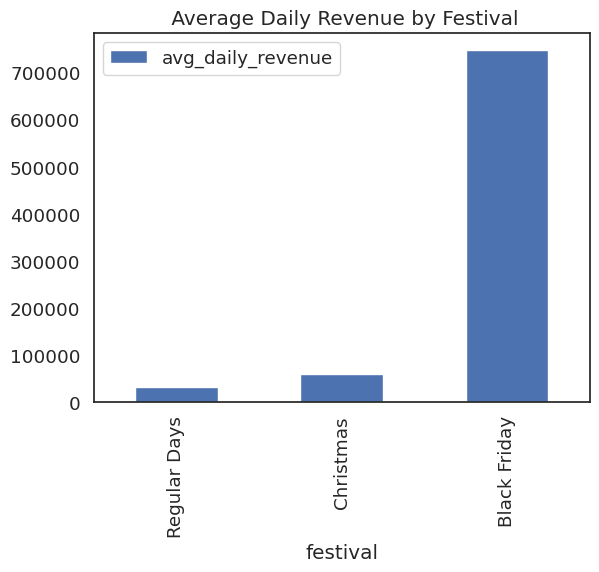

In [ ]:
festival_summary.plot(
    x='festival',
    y='avg_daily_revenue',
    kind='bar',
    title=' Average Daily Revenue by Festival'
);


let's plot in Seaborn

/tmp/ipykernel_6315/2792915902.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


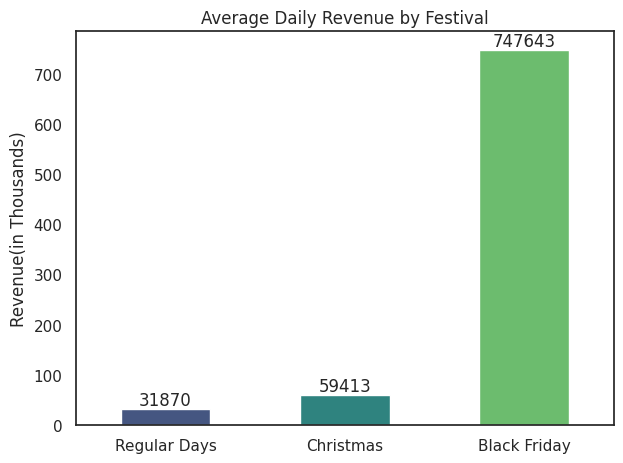

In [ ]:
import seaborn as sns
import matplotlib.ticker as mtick
sns.set_theme(style="white")

ax = sns.barplot(
    data=festival_summary,
    x='festival',
    y='avg_daily_revenue',
    palette='viridis',
    width=0.5
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

ax.yaxis.set_major_formatter(lambda x, pos: f'{x/1000:.0f}')
ax.set_title("Average Daily Revenue by Festival")
ax.set_xlabel("")
ax.set_ylabel("Revenue(in Thousands)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_6315/1329983095.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


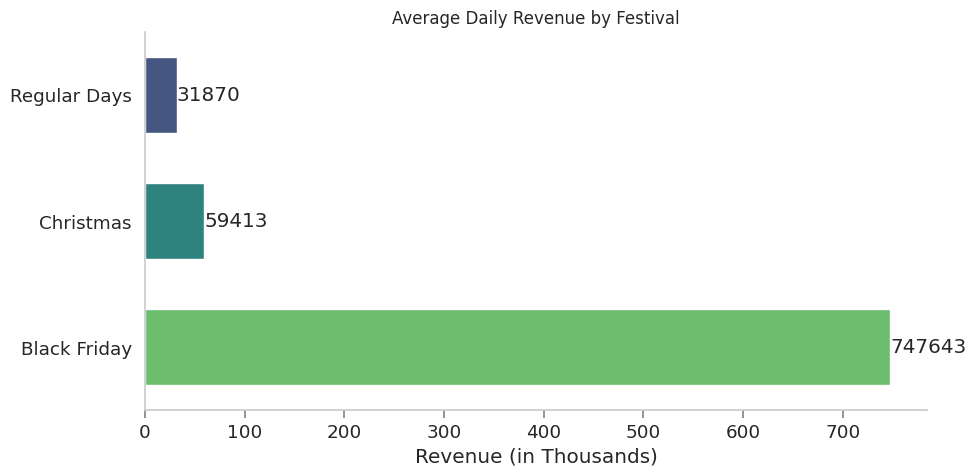

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=festival_summary,
    y='festival',
    x='avg_daily_revenue',
    palette='viridis',
    width=0.6
)
# Remove grid
ax.grid(False)

# Remove right spine
sns.despine(right=True)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

# Format axis
ax.xaxis.set_major_formatter(lambda x, pos: f'{x/1000:.0f}')
ax.set_title("Average Daily Revenue by Festival", fontsize=12,)
ax.set_xlabel("Revenue (in Thousands)")
ax.set_ylabel("")
# Force x-axis ticks to appear
ax.tick_params(axis='x', which='both', bottom=True, length=6, width=1.2, color='gray')


plt.tight_layout()
plt.show();


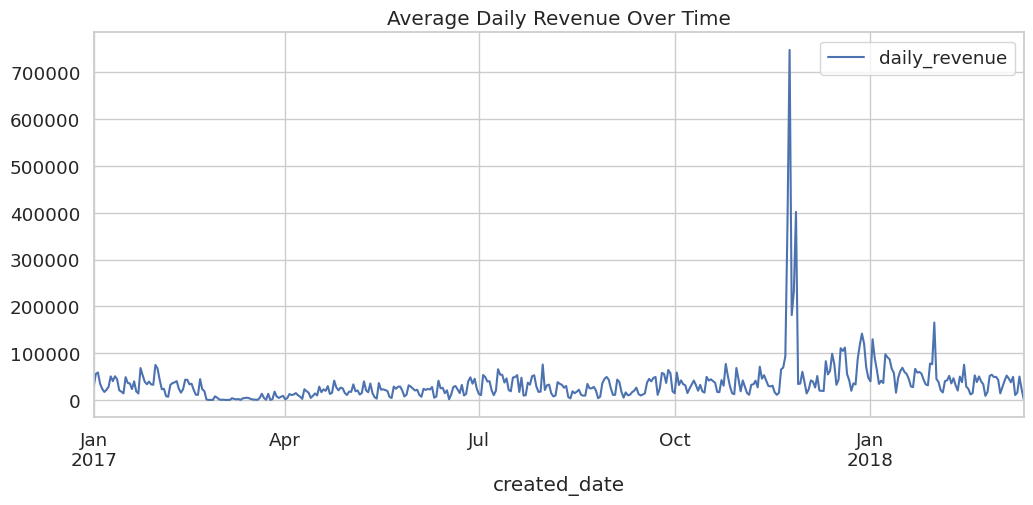

In [ ]:
daily_rev.plot(x='created_date', y='daily_revenue', figsize=(12,5), title='Average Daily Revenue Over Time');


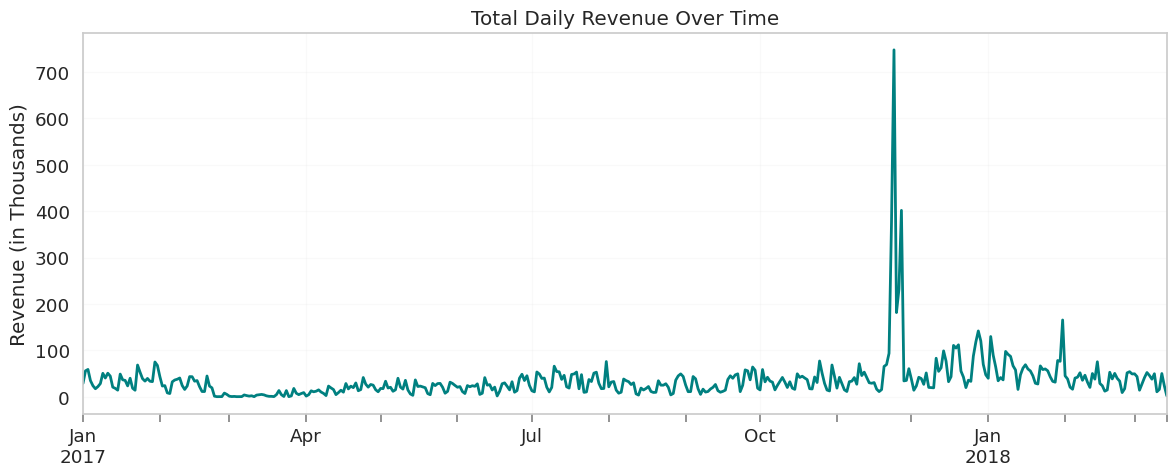

In [ ]:
import matplotlib.pyplot as plt

ax = daily_rev.plot(
    x='created_date',
    y='daily_revenue',
    figsize=(12,5),
    color='teal',
    linewidth=2,
    title='Total Daily Revenue Over Time'
)

# Format y-axis to thousands
ax.yaxis.set_major_formatter(lambda x, pos: f'{x/1000:.0f}')
ax.legend().remove() #remove label
# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Revenue (in Thousands)")
# Force x-axis ticks to appear
ax.tick_params(axis='x', which='both', bottom=True, length=6, width=1.2, color='gray')
# Improve grid for readability
ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()


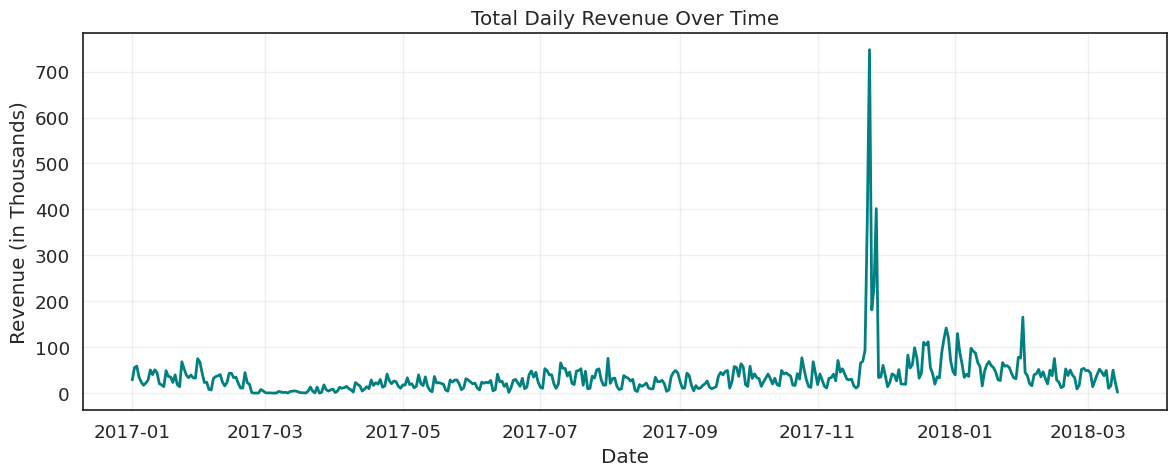

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(12,5))

ax = sns.lineplot(
    data=daily_rev,
    x='created_date',
    y='daily_revenue',
    color='teal',
    linewidth=2
)

# Title and labels
ax.set_title("Total Daily Revenue Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (in Thousands)")

# Scale y-axis to thousands
ax.yaxis.set_major_formatter(lambda x, pos: f'{x/1000:.0f}')

# Light grid for readability
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Compare revenue month‑by‑month
daily_rev['month'] = daily_rev['created_date'].dt.to_period('M')

monthly_rev = (
    daily_rev.groupby('month')['daily_revenue']
    .sum()
    .reset_index()
)

monthly_rev


,month,daily_revenue
0,2017-01,1164518.15
1,2017-02,613943.68
2,2017-03,115801.55
3,2017-04,481187.24
4,2017-05,635693.29
5,2017-06,675467.97
6,2017-07,1100844.65
7,2017-08,707798.91
8,2017-09,843529.00
9,2017-10,1059487.92


In [ ]:
# Calculate month‑over‑month growth
monthly_rev['mom_growth_pct'] = monthly_rev['daily_revenue'].pct_change() * 100
monthly_rev


,month,daily_revenue,mom_growth_pct
0,2017-01,1164518.15,NaN
1,2017-02,613943.68,-47.279166
2,2017-03,115801.55,-81.138083
3,2017-04,481187.24,315.527461
4,2017-05,635693.29,32.109341
5,2017-06,675467.97,6.256898
6,2017-07,1100844.65,62.975107
7,2017-08,707798.91,-35.704015
8,2017-09,843529.00,19.176363
9,2017-10,1059487.92,25.601837


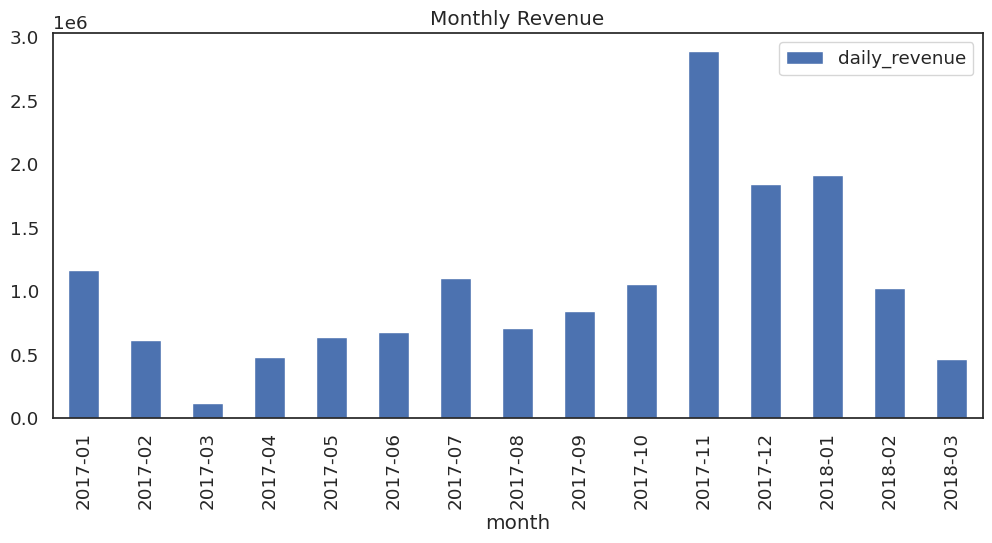

In [ ]:
daily_rev['month'] = daily_rev['created_date'].dt.to_period('M')

monthly = daily_rev.groupby('month')['daily_revenue'].sum().reset_index()

monthly.plot.bar(
    x='month',
    y='daily_revenue',
    figsize=(12,5),
    title='Monthly Revenue'
);

Let's plot in MATPLOT/ SEABORN

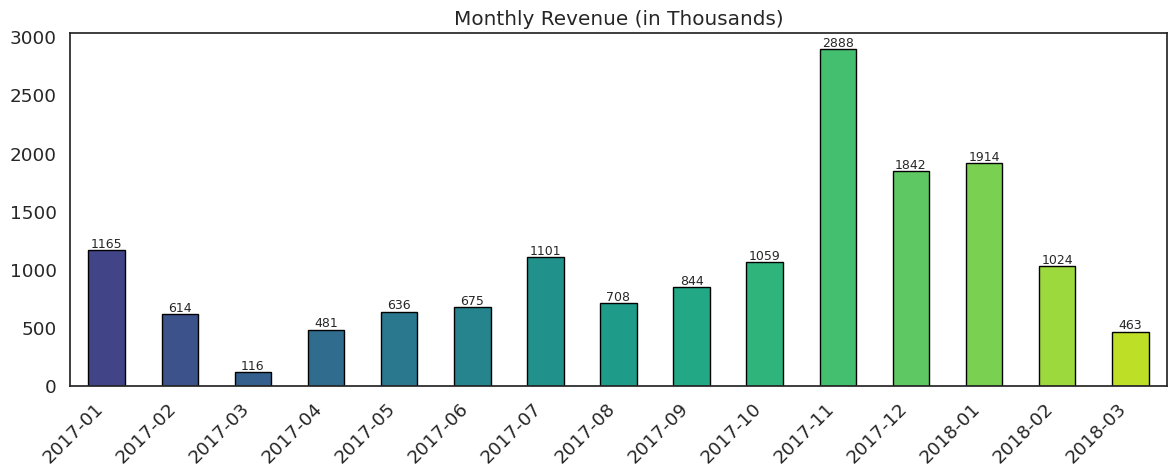

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mtick
import numpy as np
colors = cm.viridis(np.linspace(0.2, 0.9, len(monthly)))
# Create the plot
ax = monthly.plot.bar(
    x='month',
    y='daily_revenue',
    figsize=(12,5),
    color=colors,                 # custom color
    edgecolor='black',            # clean bar edges
    title='Monthly Revenue (in Thousands)'
)

# Format y-axis to thousands
ax.yaxis.set_major_formatter(lambda x, pos: f'{x/1000:.0f}')

# Add bar labels (also scaled to thousands)
for container in ax.containers:
    labels = [f"{v/1000:.0f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9)

# Improve x-axis readability
plt.xticks(rotation=45, ha='right')

# Axis labels
ax.set_ylabel("")
ax.set_xlabel("")
ax.legend().remove() #remove label

plt.tight_layout()
plt.show()


In [ ]:
merge_all['festival'] = 'Regular Days'
black_friday_mask= (
    (merge_all['created_date'].dt.month == 11) &
    (merge_all['created_date'].dt.weekday == 4) &  # Friday
    (merge_all['created_date'].dt.day.between(23, 29))
)
merge_all.loc[black_friday_mask, 'festival'] = 'Black Friday'

christmas_mask= merge_all['created_date'].dt.month == 12
merge_all.loc[christmas_mask, 'festival'] = 'Christmas'


In [ ]:
merge_all.sample(10)

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,...,price,in_stock,type,brand_code,short,long,discount_per_unit,discount_total,revenue,festival
19330,1295501,378777,1,WAC0237,24.99,2017-07-17 22:43:34,378777,2017-07-17 22:47:26,28.98,Completed,...,24.90,0.0,1229,WAC,WAC,Wacom,-0.09,-0.09,24.99,Regular Days
48114,1530313,478662,1,TUC0275,30.35,2018-01-01 19:07:51,478662,2018-01-01 19:29:21,37.34,Completed,...,39.99,0.0,12635403,TUC,TUC,Tucano,9.64,9.64,30.35,Regular Days
15756,1272041,367587,1,APP0206,84.99,2017-06-20 18:31:07,367587,2017-06-20 18:34:25,89.98,Completed,...,89.00,1.0,13005399,APP,APP,Apple,4.01,4.01,84.99,Regular Days
33155,1407794,426930,1,WAC0175,79.99,2017-11-14 21:37:27,426930,2017-11-14 21:50:11,92.97,Completed,...,99.99,0.0,1405,WAC,WAC,Wacom,20.00,20.00,79.99,Regular Days
8790,1182008,324765,1,ADN0035,27.99,2017-02-15 17:41:22,324765,2017-02-15 17:45:22,32.98,Completed,...,29.99,0.0,1229,ADN,ADN,Adonit,2.00,2.00,27.99,Regular Days
7536,1173522,320951,1,NTE0013,19.99,2017-02-07 15:26:53,320951,2017-02-08 11:48:23,191.97,Completed,...,26.99,1.0,12755395,NTE,NTE,NewerTech,7.00,7.00,19.99,Regular Days
49993,1546890,485520,1,HOC0021,14.99,2018-01-08 15:39:41,485520,2018-01-08 20:52:27,103.97,Completed,...,19.95,1.0,5399,HOC,HOC,Hoco Nike,4.96,4.96,14.99,Regular Days
16776,1279599,371226,1,SAN0103,22.99,2017-07-01 14:45:39,371226,2017-07-01 15:10:21,29.98,Completed,...,27.99,0.0,57445397,SAN,SAN,SanDisk,5.00,5.00,22.99,Regular Days
59581,1634912,520954,1,NES0012,244.99,2018-03-04 18:37:42,520954,2018-03-04 18:45:26,248.98,Completed,...,249.00,0.0,11905404,NES,NES,Nest,4.01,4.01,244.99,Regular Days
33028,1406865,426473,1,APP2352,3282.59,2017-11-13 18:42:16,426473,2017-11-13 18:53:12,3282.59,Completed,...,3519.00,0.0,"1,02E+12",APP,APP,Apple,236.41,236.41,3282.59,Regular Days


In [ ]:
merge_all['discount_pct'] = (merge_all['discount_per_unit']) / merge_all['price'] * 100


In [ ]:
merge_all.sample(10)

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,...,in_stock,type,brand_code,short,long,discount_per_unit,discount_total,revenue,festival,discount_pct
4138,1151779,311802,1,WAC0171,54.99,2017-01-18 20:30:32,311802,2017-01-18 20:34:33,58.98,Completed,...,0.0,1405,WAC,WAC,Wacom,25.00,25.00,54.99,Regular Days,31.253907
48861,1534607,480510,1,OTT0102,22.99,2018-01-03 10:04:29,480510,2018-01-03 12:51:16,36.97,Completed,...,0.0,11865403,OTT,OTT,Otterbox,7.00,7.00,22.99,Regular Days,23.341114
8349,1179161,323595,1,QDO0010,9.99,2017-02-13 15:25:15,323595,2017-02-13 16:11:00,13.98,Completed,...,0.0,13555403,QDO,QDO,QDos,15.00,15.00,9.99,Regular Days,60.024010
1529,1134738,304660,1,WDT0344,154.99,2017-01-08 10:09:08,304660,2017-01-08 10:16:30,401.97,Completed,...,0.0,12655397,WDT,WDT,Western Digital,15.00,15.00,154.99,Regular Days,8.824048
10900,1230853,347519,1,SAN0133,39.99,2017-04-19 19:08:17,347519,2017-04-19 19:17:22,56.98,Completed,...,0.0,42945397,SAN,SAN,SanDisk,10.00,10.00,39.99,Regular Days,20.004001
21528,1309707,384946,1,SAT0038,59.99,2017-08-02 13:29:47,384946,2017-08-01 09:36:31,59.99,Completed,...,1.0,5384,SAT,SAT,Satechi,20.00,20.00,59.99,Regular Days,25.003125
11751,1235969,349942,1,WDT0249,239.99,2017-04-26 12:28:36,349942,2017-04-26 12:31:54,239.99,Completed,...,1.0,12655397,WDT,WDT,Western Digital,15.01,15.01,239.99,Regular Days,5.886275
47124,1523509,475605,2,WDT0140,82.64,2017-12-28 22:38:55,475605,2017-12-28 22:57:34,513.70,Completed,...,1.0,12655397,WDT,WDT,Western Digital,16.36,32.72,165.28,Christmas,16.525253
42357,1488378,459628,1,HOC0020,26.99,2017-12-11 11:40:17,459628,2017-12-11 12:05:26,105.93,Completed,...,1.0,1515,HOC,HOC,Hoco Nike,8.00,8.00,26.99,Christmas,22.863675
15770,1272134,367624,2,BEL0212,16.99,2017-06-20 22:02:10,367624,2017-06-20 22:08:38,40.97,Completed,...,1.0,1230,BEL,BEL,Belkin,3.00,6.00,33.98,Regular Days,15.007504


In [ ]:
top_products = (
    merge_all.groupby(['festival', 'name'])['product_quantity']
    .sum()
    .reset_index()
    .sort_values(['festival', 'product_quantity'], ascending=[True, False])
    .groupby('festival')
    .head(10)
)
top_products

,festival,name,product_quantity
717,Black Friday,SanDisk Ultra 16GB microSDHC Memory Card A1,72
59,Black Friday,Apple Lightning Cable Connector to USB 1m Whit...,58
44,Black Friday,AirPods Apple Bluetooth Headset for iPhone iPa...,54
403,Black Friday,IPhone AppleCare Protection Plan,52
297,Black Friday,Crucial MX300 275GB SSD Disk,47
695,Black Friday,"Red 4TB WD 35 ""Mac PC hard drive and NAS",43
26,Black Friday,512GB Samsung SSD 850 PRO,37
560,Black Friday,Netatmo home thermostat for iPhone and iPad,34
666,Black Friday,Plantronics BackBeat Fit Wireless Headphones B...,34
773,Black Friday,Sonos Play 1 Bluetooth Speaker White,28


In [ ]:
top_products = (
    merge_all.groupby(['festival', 'name'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['festival', 'revenue'], ascending=[True, False])
    .groupby('festival')
    .head(10)
)
top_products

,festival,name,revenue
90,Black Friday,"Apple MacBook Pro 15 ""Core i7 Touch Bar 29Ghz ...",26537.31
159,Black Friday,"Apple iMac 27 ""Core i5 Retina 5K 34GHz | 16GB ...",12435.54
439,Black Friday,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",10980.00
88,Black Friday,"Apple MacBook Pro 15 ""Core i7 Touch Bar 28GHz ...",9994.36
79,Black Friday,"Apple MacBook Pro 13 ""Core i5 23GHz | 8GB RAM ...",9513.54
155,Black Friday,"Apple iMac 27 ""Core i5 3.4Ghz 5K Retina | 8GB ...",9442.95
169,Black Friday,"Apple iMac 27 ""Core i7 Retina 5K 42GHz | 16GB ...",8968.77
44,Black Friday,AirPods Apple Bluetooth Headset for iPhone iPa...,8316.00
78,Black Friday,"Apple MacBook Pro 13 ""Core i5 23GHz | 8GB RAM ...",8067.54
64,Black Friday,Apple Mac Pro 35GHz 6 cores | 32GB RAM | 512GB...,7955.18


In [ ]:
merge_all.groupby('festival')['discount_pct'].mean().round(2)

,discount_pct
festival,
Black Friday,21.81
Christmas,18.68
Regular Days,20.75


Plotting a graph in SEABORN

/tmp/ipykernel_6315/2421602327.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


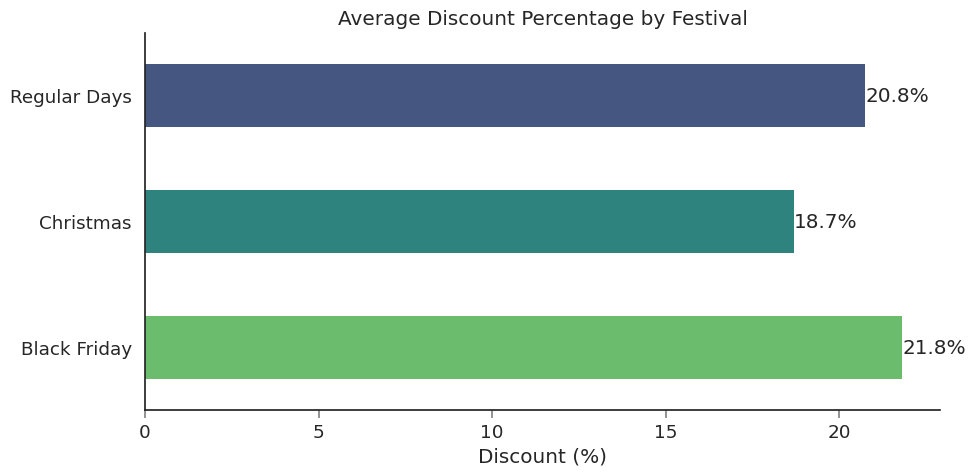

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", font_scale=1.2)
festival_discount = (
    merge_all.groupby('festival')['discount_pct']
    .mean()
    .reset_index()
)

# Define the order you want
order = ["Regular Days", "Christmas", "Black Friday"]

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=festival_discount,
    y='festival',
    x='discount_pct',
    palette='viridis',
    width=0.5,
    linewidth=0,
    order=order
)
# Remove grid
ax.grid(False)

# Remove right spine
sns.despine(right=True)
# Labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

# Title and labels
ax.set_title("Average Discount Percentage by Festival")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("")
# Force x-axis ticks to appear
ax.tick_params(axis='x', which='both', bottom=True, length=6, width=1.2, color='gray')
plt.tight_layout()
plt.show()


Although Black Friday revenue increased by over 2200%, the average discount percentage only increased slightly (from 20.75% to 21.81%). This indicates that the revenue spike was driven primarily by higher sales volume and a shift toward high‑value products, rather than significantly deeper discounts.

Black Friday success came from more units sold and more expensive units sold, not deeper discounts.

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1hDSzIA3_xxKtbuiFtQhy3oxxWOZopzi-/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qa = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1_B-hYrpY5aiJwqZsmDKL-YUuIOwsaiz9/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qa = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/19bh0hePiWgVyuFuFDFtysckFj3HjKvN0/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
product_category_df = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1_JJj8BVRWyXVUZyA4CSyooWqKKdaAUKc/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_qa = pd.read_csv(path)

In [ ]:
products_new = product_category_df.copy()
products_new

,sku,name,desc,price,promo_price,in_stock,type,short,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,49.9,1,8696,RAI,iPhone/Computer Accessories
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,58.9,0,13855401,APP,Cables and Adapters
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,56.9,0,1387,APP,Mouses
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,22.9,0,1230,APP,Batteries
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,319.9,1,1364,KIN,RAM
...,...,...,...,...,...,...,...,...,...
9987,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,26.9,1,12282,BEL,Others
9988,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,64.9,1,1392,THU,Backpacks
9989,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,64.9,1,1392,THU,Backpacks
9990,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,64.9,0,1392,THU,Backpacks


In [ ]:
# products_new.head()
# products_new.info()
products_new['category'].nunique()


32

In [ ]:
merge_category = merge_all.merge(products_new, on='sku', how='left')


In [ ]:
merge_category

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,...,festival,discount_pct,name_y,desc_y,price_y,promo_price,in_stock_y,type_y,short_y,category
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,...,Regular Days,22.134776,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,49.9,1.0,12755395,OWC,Others
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,...,Regular Days,17.254902,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,16.9,0.0,5720,IOT,iPhone/Computer Accessories
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,...,Regular Days,18.887640,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,64.9,1.0,13005399,APP,Cables and Adapters
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,...,Regular Days,20.037706,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",IMac desktop computer 27 inch Retina 5K RAM 32...,3209.00,2667.9,0.0,1282,PAC,Apple Computers
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,...,Regular Days,20.898818,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,70.7,0.0,1298,CRU,Computer Accessories
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,...,Regular Days,60.040000,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.9,1.0,1230,APP,Batteries
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,...,Regular Days,60.040000,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.9,1.0,1230,APP,Batteries
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,...,Regular Days,60.040000,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.9,1.0,1230,APP,Batteries
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,...,Regular Days,60.040000,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.9,1.0,1230,APP,Batteries


In [ ]:
merge_category.groupby(['festival', 'category'])['product_quantity'].sum()

festival      category                     
Black Friday  Apple Computers                   147
              Apple Watches                      53
              AppleCare Extended Warranties      91
              Armbands                           12
              Backpacks                           9
                                               ... 
Regular Days  iPads                             586
              iPhone Cases                     3962
              iPhone/Computer Accessories      4039
              iPhones                          2062
              iPods                              66
Name: product_quantity, Length: 93, dtype: int64

In [ ]:
merge_category.groupby(['festival', 'category'])['revenue'].sum()

festival      category                     
Black Friday  Apple Computers                   299454.04
              Apple Watches                      19869.12
              AppleCare Extended Warranties       8459.62
              Armbands                            1344.34
              Backpacks                            401.06
                                                  ...    
Regular Days  iPads                             369455.59
              iPhone Cases                      104522.81
              iPhone/Computer Accessories       440784.80
              iPhones                          1253102.45
              iPods                              10074.67
Name: revenue, Length: 93, dtype: float64

In [ ]:
cat_rev = (
    merge_category.groupby(['festival', 'category'])['revenue']
    .sum()
    .reset_index()
)

festival_totals = (
    merge_category.groupby('festival')['revenue']
    .sum()
    .reset_index()
    .rename(columns={'revenue': 'festival_total'})
)

cat_rev = cat_rev.merge(festival_totals, on='festival')
cat_rev['pct_contribution'] = cat_rev['revenue'] / cat_rev['festival_total'] * 100


In [ ]:
cat_rev

,festival,category,revenue,festival_total,pct_contribution
0,Black Friday,Apple Computers,299454.04,747642.75,40.053092
1,Black Friday,Apple Watches,19869.12,747642.75,2.657569
2,Black Friday,AppleCare Extended Warranties,8459.62,747642.75,1.131506
3,Black Friday,Armbands,1344.34,747642.75,0.179810
4,Black Friday,Backpacks,401.06,747642.75,0.053643
...,...,...,...,...,...
88,Regular Days,iPads,369455.59,12939282.35,2.855302
89,Regular Days,iPhone Cases,104522.81,12939282.35,0.807794
90,Regular Days,iPhone/Computer Accessories,440784.80,12939282.35,3.406563
91,Regular Days,iPhones,1253102.45,12939282.35,9.684482


In [ ]:
rev_per_day = merge_category.groupby('festival')['revenue'].sum()

In [ ]:
rev_per_day

,revenue
festival,
Black Friday,747642.75
Christmas,1841790.94
Regular Days,12939282.35


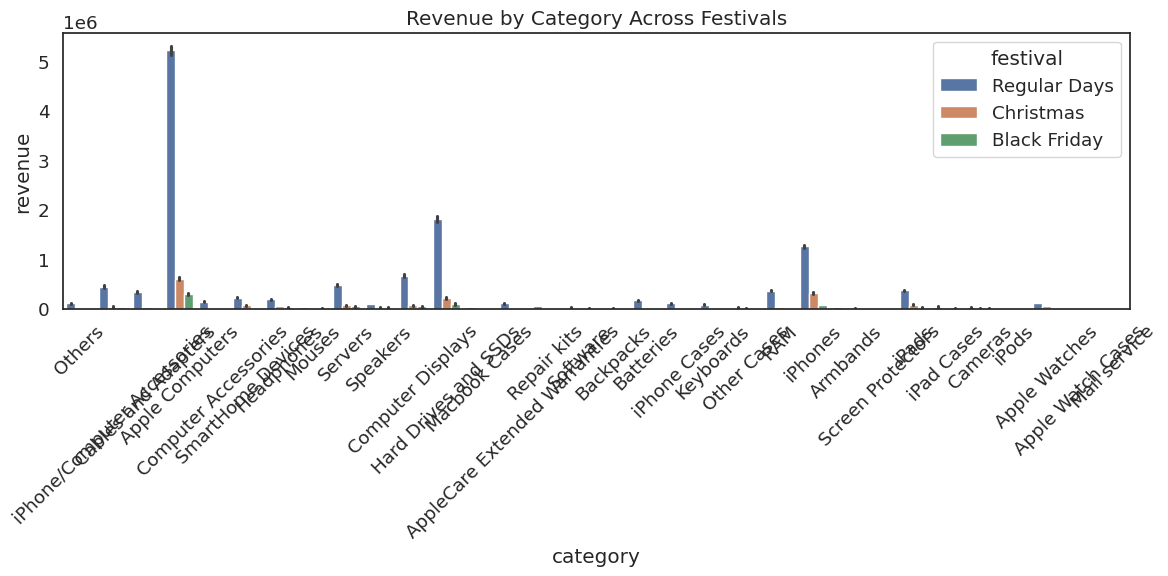

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(
    data=merge_category,
    x='category',
    y='revenue',
    hue='festival',
    estimator='sum'
)

plt.title("Revenue by Category Across Festivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


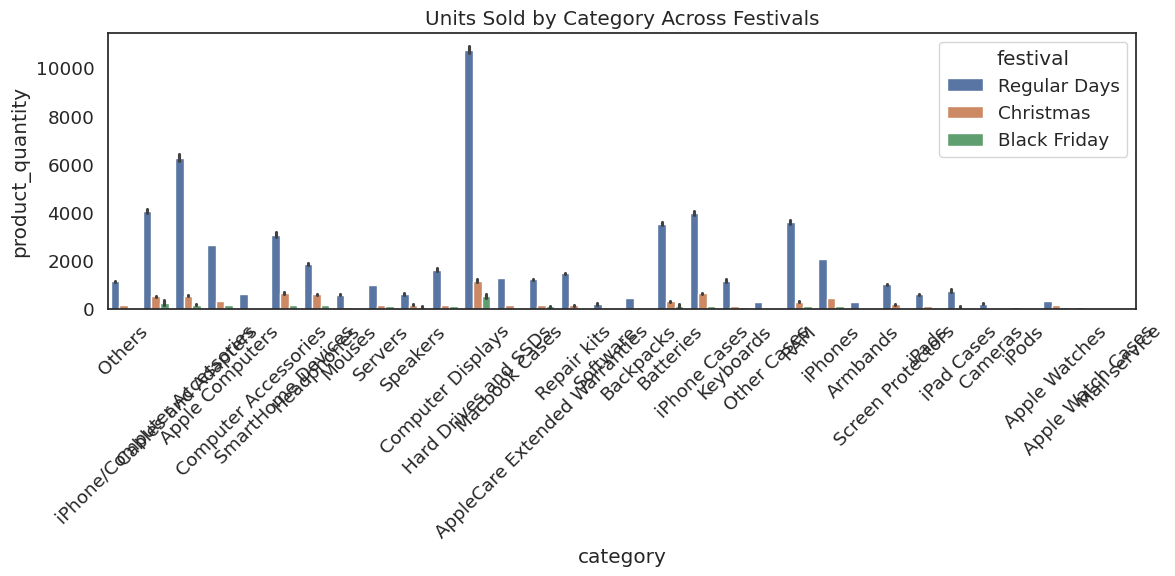

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=merge_category,
    x='category',
    y='product_quantity',
    hue='festival',
    estimator='sum'
)

plt.title("Units Sold by Category Across Festivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


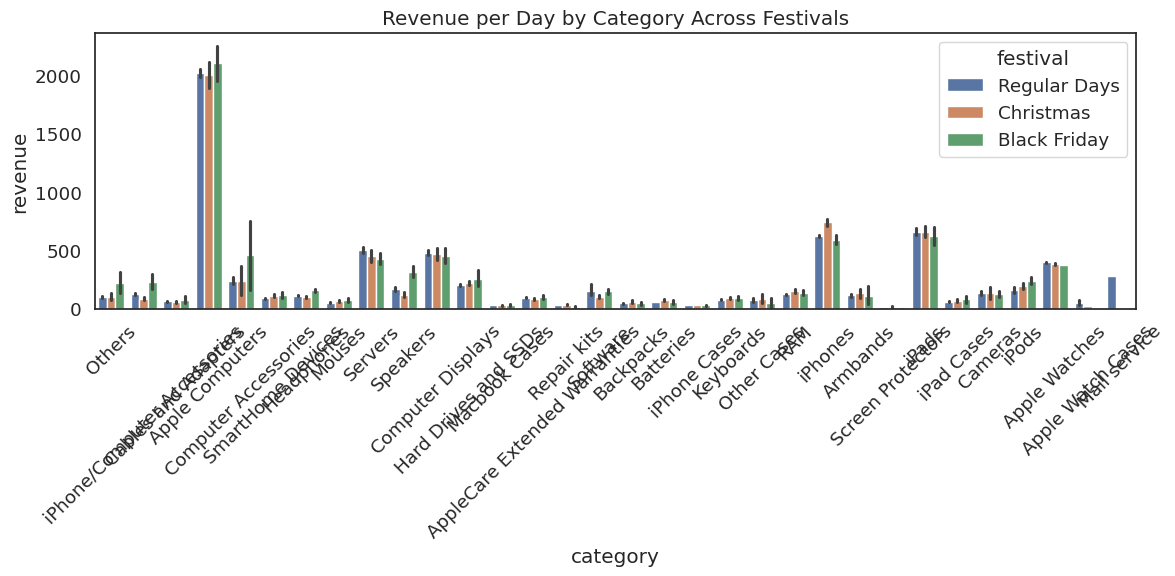

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(
    data=merge_category,
    x='category',
    y='revenue',
    hue='festival'
)

plt.title("Revenue per Day by Category Across Festivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


We recommend to reduce the discount by 2.5 %. Let's find out what it impacts on revenue

In [112]:
# 1. Convert discount_pct from percent to decimal
merge_all['discount_pct_decimal'] = merge_all['discount_pct'] / 100

# 2. Reduce discount by 2 percentage points (0.025 in decimal)
merge_all['discount_new'] = (merge_all['discount_pct_decimal'] - 0.025).clip(0, 1)

# 3. Recompute net prices
merge_all['net_price_old'] = merge_all['unit_price'] * (1 - merge_all['discount_pct_decimal'])
merge_all['net_price_new'] = merge_all['unit_price'] * (1 - merge_all['discount_new'])

# 4. Recompute revenues
merge_all['revenue_old'] = merge_all['net_price_old'] * merge_all['product_quantity']
merge_all['revenue_new'] = merge_all['net_price_new'] * merge_all['product_quantity']

# 5. Totals
total_old = merge_all['revenue_old'].sum()
total_new = merge_all['revenue_new'].sum()

impact = total_new - total_old
pct_change = (total_new / total_old - 1) * 100

print(f"Old revenue: {total_old:,.2f}")
print(f"New revenue: {total_new:,.2f}")
print(f"Change: {impact:,.2f} ({pct_change:.2f}%)")


Old revenue: 13,246,316.85
New revenue: 13,548,711.55
Change: 302,394.70 (2.28%)


In [113]:
merge_all

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,...,revenue,festival,discount_pct,discount_new,net_price_old,net_price_new,revenue_old,revenue_new,discount_pct_decimal,rev_delta
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,...,47.49,Regular Days,22.134776,0.196348,36.978195,38.165445,36.978195,38.165445,0.221348,0.9498
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,...,18.99,Regular Days,17.254902,0.147549,15.713294,16.188044,15.713294,16.188044,0.172549,0.3798
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,...,72.19,Regular Days,18.887640,0.163876,58.555012,60.359762,58.555012,60.359762,0.188876,1.4438
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,...,2565.99,Regular Days,20.037706,0.175377,2051.824456,2115.974206,2051.824456,2115.974206,0.200377,51.3198
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,...,60.90,Regular Days,20.898818,0.183988,48.172620,49.695120,48.172620,49.695120,0.208988,1.2180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,...,9.99,Regular Days,60.040000,0.575400,3.992004,4.241754,3.992004,4.241754,0.600400,0.1998
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,...,19.98,Regular Days,60.040000,0.575400,3.992004,4.241754,7.984008,8.483508,0.600400,0.3996
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,...,19.98,Regular Days,60.040000,0.575400,3.992004,4.241754,7.984008,8.483508,0.600400,0.3996
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,...,29.97,Regular Days,60.040000,0.575400,3.992004,4.241754,11.976012,12.725262,0.600400,0.5994


/tmp/ipykernel_6315/2495895351.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette=['#1f77b4', '#2ca02c'], width=0.5)


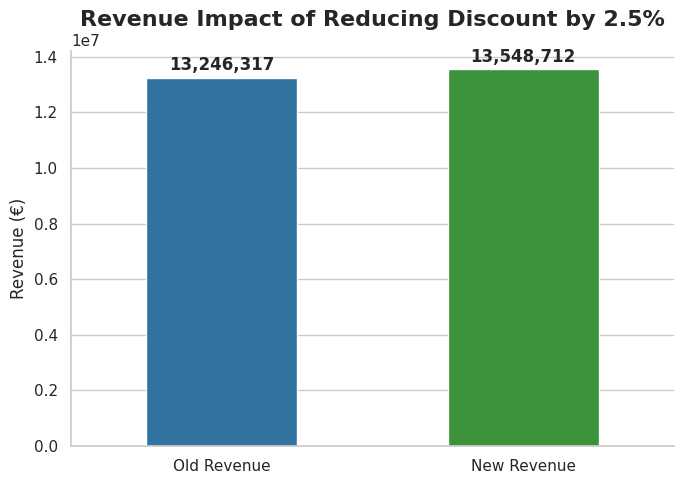

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7,5))

# Data
labels = ['Old Revenue', 'New Revenue']
values = [total_old, total_new]

# Plot
ax = sns.barplot(x=labels, y=values, palette=['#1f77b4', '#2ca02c'], width=0.5)

# Add value labels
for i, v in enumerate(values):
    ax.text(i, v + (0.01 * max(values)), f"{v:,.0f}",
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Titles and labels
plt.title("Revenue Impact of Reducing Discount by 2.5%", fontsize=16, fontweight='bold')
plt.ylabel("Revenue (€)", fontsize=12)
plt.xlabel("")

sns.despine()
plt.tight_layout()
plt.show()


/tmp/ipykernel_6315/2653133743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=bars, palette=colors)


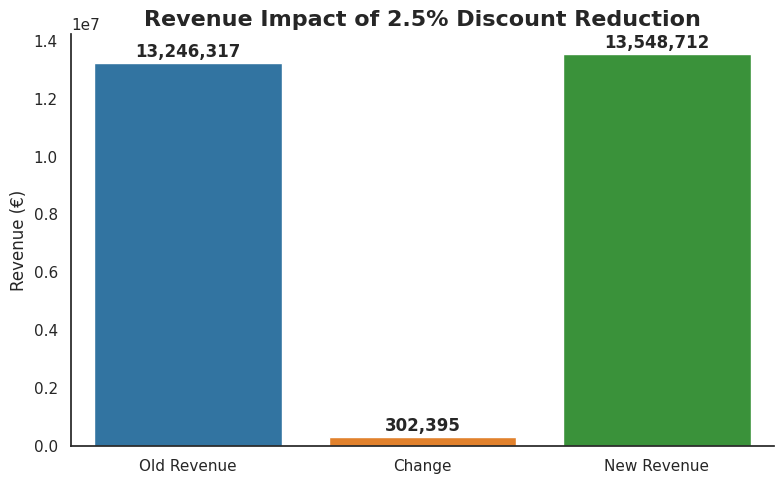

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(8,5))

bars = [total_old, impact, total_new]
labels = ["Old Revenue", "Change", "New Revenue"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

ax = sns.barplot(x=labels, y=bars, palette=colors)

for i, v in enumerate(bars):
    ax.text(
        i,
        v + (0.005 * max(bars)),
        f"{v:,.0f}",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Revenue Impact of 2.5% Discount Reduction", fontsize=16, fontweight='bold')
plt.ylabel("Revenue (€)", fontsize=12)
plt.xlabel("")

sns.despine()
plt.tight_layout()
plt.show()


In [121]:
import pandas as pd

# Sensitivity levels in percentage points
scenarios = [-0.05, -0.025, -0.01, 0.01, 0.02]

results = []

for change in scenarios:
    # Adjust discount (discount_pct_decimal already exists)
    adj = (merge_all['discount_pct_decimal'] + change).clip(0, 1)

    # Compute new net price and revenue
    net_price = merge_all['unit_price'] * (1 - adj)
    revenue = net_price * merge_all['product_quantity']

    # Store results
    results.append({
        "Discount Change (pp)": change * 100,   # convert to percentage points
        "Total Revenue": revenue.sum()
    })

sensitivity_df = pd.DataFrame(results)
sensitivity_df["Δ vs Current"] = sensitivity_df["Total Revenue"] - total_old
sensitivity_df["% Change"] = (sensitivity_df["Total Revenue"] / total_old - 1) * 100

sensitivity_df


,Discount Change (pp),Total Revenue,Δ vs Current,% Change
0,-5.0,1.386508e+07,618763.436665,4.671211
1,-2.5,1.354871e+07,302394.704062,2.282859
2,-1.0,1.334283e+07,96509.735443,0.728578
3,1.0,1.305555e+07,-190762.000718,-1.440114
4,2.0,1.290851e+07,-337809.895965,-2.550218


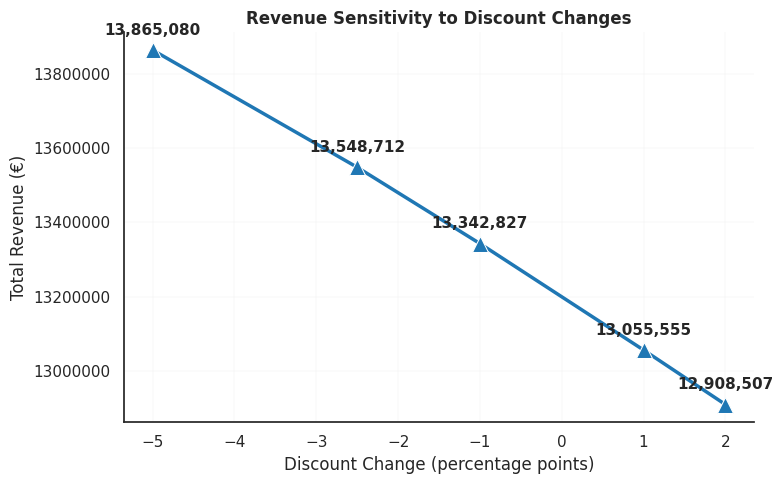

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(8,5))

# Subtle grid
plt.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, alpha=0.3)

ax = sns.lineplot(
    data=sensitivity_df,
    x="Discount Change (pp)",
    y="Total Revenue",
    marker="^",
    markersize=12,      # bigger marker
    linewidth=2.5,
    color="#1f77b4"
)

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='y')

# Remove auto-legend
plt.legend([], [], frameon=False)

# Add value labels
for i in range(len(sensitivity_df)):
    x = sensitivity_df["Discount Change (pp)"].iloc[i]
    y = sensitivity_df["Total Revenue"].iloc[i]
    plt.text(
        x,
        y + (0.003 * sensitivity_df["Total Revenue"].max()),
        f"{y:,.0f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Revenue Sensitivity to Discount Changes", fontsize=12, fontweight='bold')
plt.xlabel("Discount Change (percentage points)", fontsize=12)
plt.ylabel("Total Revenue (€)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


In [143]:
import numpy as np

# Copy the decimal discount column
d = merge_all['discount_pct_decimal']

# Create a new adjusted discount column
discount_adj = d.copy()

# 1) Apply -3 percentage points to all rows
discount_adj = discount_adj - 0.03

# 2) Apply -1 percentage point ONLY to Black Friday + Xmas
mask_festivals = merge_all['festival'].isin(['Black Friday', 'Christmas'])
discount_adj[mask_festivals] = d[mask_festivals] - 0.01

# Clip to valid range
discount_adj = discount_adj.clip(0, 1)

# Compute new net price and revenue
net_price_new = merge_all['unit_price'] * (1 - discount_adj)
revenue_new = net_price_new * merge_all['product_quantity']

# Old revenue (baseline)
revenue_old = merge_all['revenue_old']   # already computed earlier

# Totals
total_old = revenue_old.sum()
total_new = revenue_new.sum()

impact = total_new - total_old
pct_change = (total_new / total_old - 1) * 100

print(f"Old revenue: {total_old:,.2f}")
print(f"New revenue: {total_new:,.2f}")
print(f"Change: {impact:,.2f} ({pct_change:.2f}%)")


Old revenue: 13,246,316.85
New revenue: 13,569,361.83
Change: 323,044.99 (2.44%)


/tmp/ipykernel_6315/1241287024.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


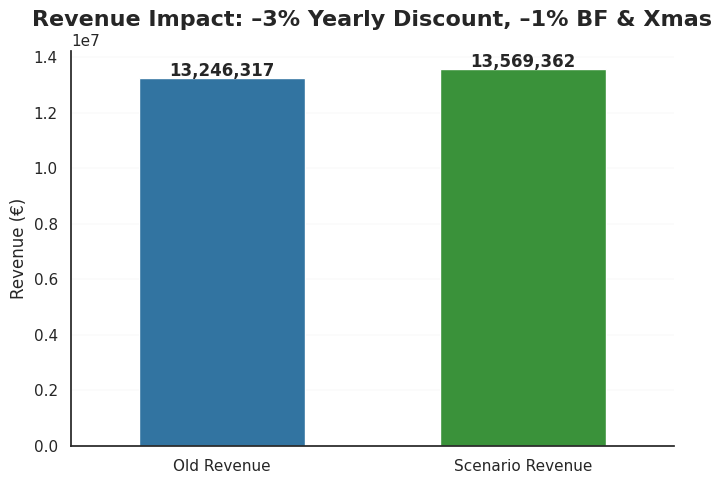

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(7,5))

# Subtle grid
plt.grid(True, which='major', axis='y', linestyle='-', linewidth=0.3, alpha=0.3)

labels = ['Old Revenue', 'Scenario Revenue']
values = [total_old, total_new]

ax = sns.barplot(
    x=labels,
    y=values,
    palette=['#1f77b4', '#2ca02c'],
    width=0.55
)

# Add value labels
for i, v in enumerate(values):
    ax.text(
        i,
        v + (0.005 * max(values)),
        f"{v:,.0f}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Revenue Impact: –3% Yearly Discount, –1% BF & Xmas", fontsize=16, fontweight='bold')
plt.ylabel("Revenue (€)", fontsize=12)
plt.xlabel("")

sns.despine()
plt.tight_layout()
plt.show()
